# Dode punten: invloed van r2

Deze notebook vergelijkt alleen de drie gevraagde waarden `r2 = 0.95 m`, `0.99 m` en `1.01 m`. De focus ligt op conditiegetal, transmissiehoeken, scharnierkrachten, aandrijfmoment en vermogen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

plt.rcParams.update({
    'figure.figsize': (8, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
})

In [2]:
# Function to rotate a vector z over an angle theta:
def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    return np.dot(rotation_matrix, z)
# Define function to compute "gap" in position closure:
def loop_closure_eqs(theta_init, theta1, r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y):
    theta2 = theta_init[0]
    theta3 = theta_init[1]
    theta4 = theta_init[2]
    theta5 = theta_init[3]
    theta6 = theta_init[4]
    theta7 = theta_init[5]
    

    # Loop closure gaps:
    F1 = r1 * np.cos(theta1) + r2 * np.cos(theta2) + rDC * np.cos(theta3) - rAD_x
    F2 = r1 * np.sin(theta1) + r2 * np.sin(theta2) + rDC * np.sin(theta3) - rAD_y

    F3 = -rDF * np.cos(theta3) + r6 * np.cos(theta4) - r7 * np.cos(theta5) - rDH_x
    F4 = -rDF * np.sin(theta3) + r6 * np.sin(theta4) - r7 * np.sin(theta5) + rDH_y

    F5 = rED * np.cos(theta3) + r4 * np.cos(theta6) - rIJ * np.cos(theta7) - rDI_x
    F6 = rED * np.sin(theta3) + r4 * np.sin(theta6) - rIJ * np.sin(theta7) - rDI_y

    return [F1, F2, F3, F4, F5, F6]

In [3]:
def base_geometry(r2):
    return dict(
        r1=0.11, r2=r2, r3=1.53, r4=1.01, r5=1.13, r6=0.90, r7=0.50,
        rDC=0.16, rDF=0.41, rED=0.28, rIJ=0.28,
        grondA_x=0.00, grondA_y=0.00,
        grondD_x=0.76, grondD_y=0.66,
        grondH_x=1.79, grondH_y=0.01,
        grondI_x=1.77, grondI_y=0.66,
    )

def add_derived_geometry(g):
    g = dict(g)
    g['rAD_x'] = abs(g['grondD_x'] - g['grondA_x'])
    g['rAD_y'] = abs(g['grondD_y'] - g['grondA_y'])
    g['rDI_x'] = abs(g['grondD_x'] - g['grondI_x'])
    g['rDI_y'] = abs(g['grondD_y'] - g['grondI_y'])
    return g

def input_motion(omega=4.2, Ts=0.01, theta1_0_deg=65):
    t_begin = 0.0
    t_end = 2*np.pi/omega
    num_steps = int(np.ceil((t_end - t_begin) / Ts))
    t = np.linspace(t_begin, t_end, num_steps + 1)
    theta1 = np.deg2rad(theta1_0_deg) + omega*t
    dtheta1 = omega*np.ones_like(t)
    ddtheta1 = np.zeros_like(t)
    return t, theta1, dtheta1, ddtheta1

def effective_transmission_angle(theta_a, theta_b):
    gamma = np.abs(theta_a - theta_b)
    gamma = np.mod(gamma, 2*np.pi)
    gamma = np.minimum(gamma, 2*np.pi - gamma)
    return np.minimum(gamma, np.pi - gamma)

def cycle_average(signal, t):
    return np.trapezoid(signal, t) / (t[-1] - t[0])

In [4]:
# Function to compute the kinematics
def kinematics(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1, theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init, t):
    optim_options = {"full_output":True}  # options for fsolve

    theta2 = np.zeros_like(t)
    theta3 = np.zeros_like(t)
    theta4 = np.zeros_like(t)
    theta5 = np.zeros_like(t)
    theta6 = np.zeros_like(t)
    theta7 = np.zeros_like(t)

    dtheta2 = np.zeros_like(t)
    dtheta3 = np.zeros_like(t)
    dtheta4 = np.zeros_like(t)
    dtheta5 = np.zeros_like(t)
    dtheta6 = np.zeros_like(t)
    dtheta7 = np.zeros_like(t)

    ddtheta2 = np.zeros_like(t)
    ddtheta3 = np.zeros_like(t)
    ddtheta4 = np.zeros_like(t)
    ddtheta5 = np.zeros_like(t)
    ddtheta6 = np.zeros_like(t)
    ddtheta7 = np.zeros_like(t)

    cond = np.zeros_like(t)
    fsolve_failures = 0

  # numerically solving the position closure at all sampling times:
    for k, time in enumerate(t):
      # Position Analysis
      x, _, ier, message  = fsolve(lambda x: loop_closure_eqs(x, theta1[k], r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y), [theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init], **optim_options)

      if ier != 1:
          fsolve_failures += 1

      theta2[k] = x[0]
      theta3[k] = x[1]
      theta4[k] = x[2]
      theta5[k] = x[3]
      theta6[k] = x[4]
      theta7[k] = x[5]

      # velocity closure:
      A = np.array([
        [-r2*np.sin(theta2[k]), -rDC*np.sin(theta3[k]), 0, 0, 0, 0],
        [ r2*np.cos(theta2[k]),  rDC*np.cos(theta3[k]), 0, 0, 0, 0],
        [0,  rDF*np.sin(theta3[k]), -r6*np.sin(theta4[k]),  r7*np.sin(theta5[k]), 0, 0],
        [0, -rDF*np.cos(theta3[k]),  r6*np.cos(theta4[k]), -r7*np.cos(theta5[k]), 0, 0],
        [0, -rED*np.sin(theta3[k]), 0, 0, -r4*np.sin(theta6[k]),  rIJ*np.sin(theta7[k])],
        [0,  rED*np.cos(theta3[k]), 0, 0,  r4*np.cos(theta6[k]), -rIJ*np.cos(theta7[k])]
      ])

      B = np.array([
        r1*np.sin(theta1[k])*dtheta1[k],
        -r1*np.cos(theta1[k])*dtheta1[k],
        0,
        0,
        0,
        0
      ])

      x = np.linalg.solve(A, B)
      cond[k]  = np.linalg.cond(A)

      dtheta2[k] = x[0]
      dtheta3[k] = x[1]
      dtheta4[k] = x[2]
      dtheta5[k] = x[3]
      dtheta6[k] = x[4]
      dtheta7[k] = x[5]

      A = np.array([
        [-r2*np.sin(theta2[k]), -rDC*np.sin(theta3[k]), 0, 0, 0, 0],
        [ r2*np.cos(theta2[k]),  rDC*np.cos(theta3[k]), 0, 0, 0, 0],
        [0,  rDF*np.sin(theta3[k]), -r6*np.sin(theta4[k]),  r7*np.sin(theta5[k]), 0, 0],
        [0, -rDF*np.cos(theta3[k]),  r6*np.cos(theta4[k]), -r7*np.cos(theta5[k]), 0, 0],
        [0, -rED*np.sin(theta3[k]), 0, 0, -r4*np.sin(theta6[k]),  rIJ*np.sin(theta7[k])],
        [0,  rED*np.cos(theta3[k]), 0, 0,  r4*np.cos(theta6[k]), -rIJ*np.cos(theta7[k])]
      ])

      B = np.array([
        r1*np.cos(theta1[k])*dtheta1[k]**2 + r1*np.sin(theta1[k])*ddtheta1[k]
        + r2*np.cos(theta2[k])*dtheta2[k]**2 + rDC*np.cos(theta3[k])*dtheta3[k]**2,

        r1*np.sin(theta1[k])*dtheta1[k]**2 - r1*np.cos(theta1[k])*ddtheta1[k]
        + r2*np.sin(theta2[k])*dtheta2[k]**2 + rDC*np.sin(theta3[k])*dtheta3[k]**2,

        -rDF*np.cos(theta3[k])*dtheta3[k]**2 + r6*np.cos(theta4[k])*dtheta4[k]**2 - r7*np.cos(theta5[k])*dtheta5[k]**2,

        -rDF*np.sin(theta3[k])*dtheta3[k]**2 + r6*np.sin(theta4[k])*dtheta4[k]**2 - r7*np.sin(theta5[k])*dtheta5[k]**2,

        rED*np.cos(theta3[k])*dtheta3[k]**2 + r4*np.cos(theta6[k])*dtheta6[k]**2 - rIJ*np.cos(theta7[k])*dtheta7[k]**2,

        rED*np.sin(theta3[k])*dtheta3[k]**2 + r4*np.sin(theta6[k])*dtheta6[k]**2 - rIJ*np.sin(theta7[k])*dtheta7[k]**2
      ])

      x = np.linalg.solve(A, B)
      
      ddtheta2[k] = x[0]
      ddtheta3[k] = x[1]
      ddtheta4[k] = x[2]
      ddtheta5[k] = x[3]
      ddtheta6[k] = x[4]
      ddtheta7[k] = x[5] 

      theta2_init = theta2[k] + (t[1] - t[0])*dtheta2[k]
      theta3_init = theta3[k] + (t[1] - t[0])*dtheta3[k]
      theta4_init = theta4[k] + (t[1] - t[0])*dtheta4[k]
      theta5_init = theta5[k] + (t[1] - t[0])*dtheta5[k]
      theta6_init = theta6[k] + (t[1] - t[0])*dtheta6[k]
      theta7_init = theta7[k] + (t[1] - t[0])*dtheta7[k]

    if fsolve_failures:
        print(f"Waarschuwing: fsolve convergeerde niet op {fsolve_failures} tijdstappen. Controleer vooral de bijna-singuliere case.")

    return theta2, theta3, theta4, theta5, theta6, theta7, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7, cond

def center_of_mass_kinematics(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                              dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
                              ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
                              r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
                              X1, X2, X3, X4, X5, X6, X7,
                              Y1, Y2, Y3, Y4, Y5, Y6, Y7):
    # link numbering follows the sketch:
    # link 4 uses theta6, link 5 uses theta7, link 6 uses theta4 and link 7 uses theta5
    cog1_A_x = -X1 * np.cos(theta1) - Y1 * np.cos(theta1 + np.pi / 2)
    cog1_A_y = -X1 * np.sin(theta1) - Y1 * np.sin(theta1 + np.pi / 2)
    cog2_B_x = -X2 * np.cos(theta2) - Y2 * np.cos(theta2 + np.pi / 2)
    cog2_B_y = -X2 * np.sin(theta2) - Y2 * np.sin(theta2 + np.pi / 2)
    cog3_D_x = -X3 * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_D_y = -X3 * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)
    cog4_E_x = -X4 * np.cos(theta6) - Y4 * np.cos(theta6 + np.pi / 2)
    cog4_E_y = -X4 * np.sin(theta6) - Y4 * np.sin(theta6 + np.pi / 2)
    cog5_I_x = -X5 * np.cos(theta7) - Y5 * np.cos(theta7 + np.pi / 2)
    cog5_I_y = -X5 * np.sin(theta7) - Y5 * np.sin(theta7 + np.pi / 2)
    cog6_F_x = -X6 * np.cos(theta4) - Y6 * np.cos(theta4 + np.pi / 2)
    cog6_F_y = -X6 * np.sin(theta4) - Y6 * np.sin(theta4 + np.pi / 2)
    cog7_H_x = -X7 * np.cos(theta5) - Y7 * np.cos(theta5 + np.pi / 2)
    cog7_H_y = -X7 * np.sin(theta5) - Y7 * np.sin(theta5 + np.pi / 2)

    omega1 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta1))
    omega2 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta2))
    omega3 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta3))
    omega4 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta6))
    omega5 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta7))
    omega6 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta4))
    omega7 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta5))

    alpha1 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta1))
    alpha2 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta2))
    alpha3 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta3))
    alpha4 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta6))
    alpha5 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta7))
    alpha6 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta4))
    alpha7 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta5))

    A_cog1_vec = np.column_stack((-cog1_A_x, -cog1_A_y, np.zeros_like(theta1)))
    B_cog2_vec = np.column_stack((-cog2_B_x, -cog2_B_y, np.zeros_like(theta1)))
    D_cog3_vec = np.column_stack((-cog3_D_x, -cog3_D_y, np.zeros_like(theta1)))
    E_cog4_vec = np.column_stack((-cog4_E_x, -cog4_E_y, np.zeros_like(theta1)))
    I_cog5_vec = np.column_stack((-cog5_I_x, -cog5_I_y, np.zeros_like(theta1)))
    F_cog6_vec = np.column_stack((-cog6_F_x, -cog6_F_y, np.zeros_like(theta1)))
    H_cog7_vec = np.column_stack((-cog7_H_x, -cog7_H_y, np.zeros_like(theta1)))

    AB_vec = np.column_stack((r1 * np.cos(theta1), r1 * np.sin(theta1), np.zeros_like(theta1)))
    DE_vec = np.column_stack((rED * np.cos(theta3), rED * np.sin(theta3), np.zeros_like(theta1)))
    DF_vec = np.column_stack((-rDF * np.cos(theta3), -rDF * np.sin(theta3), np.zeros_like(theta1)))

    vel_1 = np.cross(omega1, A_cog1_vec)
    vel_B = np.cross(omega1, AB_vec)
    vel_2 = vel_B + np.cross(omega2, B_cog2_vec)
    vel_3 = np.cross(omega3, D_cog3_vec)
    vel_E = np.cross(omega3, DE_vec)
    vel_F = np.cross(omega3, DF_vec)
    vel_4 = vel_E + np.cross(omega4, E_cog4_vec)
    vel_5 = np.cross(omega5, I_cog5_vec)
    vel_6 = vel_F + np.cross(omega6, F_cog6_vec)
    vel_7 = np.cross(omega7, H_cog7_vec)

    acc_1 = np.cross(omega1, np.cross(omega1, A_cog1_vec)) + np.cross(alpha1, A_cog1_vec)
    acc_B = np.cross(omega1, np.cross(omega1, AB_vec)) + np.cross(alpha1, AB_vec)
    acc_2 = acc_B + np.cross(omega2, np.cross(omega2, B_cog2_vec)) + np.cross(alpha2, B_cog2_vec)
    acc_3 = np.cross(omega3, np.cross(omega3, D_cog3_vec)) + np.cross(alpha3, D_cog3_vec)
    acc_E = np.cross(omega3, np.cross(omega3, DE_vec)) + np.cross(alpha3, DE_vec)
    acc_F = np.cross(omega3, np.cross(omega3, DF_vec)) + np.cross(alpha3, DF_vec)
    acc_4 = acc_E + np.cross(omega4, np.cross(omega4, E_cog4_vec)) + np.cross(alpha4, E_cog4_vec)
    acc_5 = np.cross(omega5, np.cross(omega5, I_cog5_vec)) + np.cross(alpha5, I_cog5_vec)
    acc_6 = acc_F + np.cross(omega6, np.cross(omega6, F_cog6_vec)) + np.cross(alpha6, F_cog6_vec)
    acc_7 = np.cross(omega7, np.cross(omega7, H_cog7_vec)) + np.cross(alpha7, H_cog7_vec)

    speeds = [np.linalg.norm(vel, axis=1) for vel in (vel_1, vel_2, vel_3, vel_4, vel_5, vel_6, vel_7)]

    return (
        vel_1[:, 0], vel_1[:, 1], vel_2[:, 0], vel_2[:, 1], vel_3[:, 0], vel_3[:, 1],
        vel_4[:, 0], vel_4[:, 1], vel_5[:, 0], vel_5[:, 1], vel_6[:, 0], vel_6[:, 1],
        vel_7[:, 0], vel_7[:, 1], *speeds,
        acc_1[:, 0], acc_1[:, 1], acc_2[:, 0], acc_2[:, 1], acc_3[:, 0], acc_3[:, 1],
        acc_4[:, 0], acc_4[:, 1], acc_5[:, 0], acc_5[:, 1], acc_6[:, 0], acc_6[:, 1],
        acc_7[:, 0], acc_7[:, 1]
    )


def center_of_mass_positions(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                             r1, rED, rDF,
                             grondA_x, grondA_y, grondD_x, grondD_y,
                             grondH_x, grondH_y, grondI_x, grondI_y,
                             X1, X2, X3, X4, X5, X6, X7,
                             Y1, Y2, Y3, Y4, Y5, Y6, Y7):
    cog_1_x = grondA_x + X1 * np.cos(theta1) + Y1 * np.cos(theta1 + np.pi / 2)
    cog_1_y = grondA_y + X1 * np.sin(theta1) + Y1 * np.sin(theta1 + np.pi / 2)

    point_B_x = grondA_x + r1 * np.cos(theta1)
    point_B_y = grondA_y + r1 * np.sin(theta1)
    cog_2_x = point_B_x + X2 * np.cos(theta2) + Y2 * np.cos(theta2 + np.pi / 2)
    cog_2_y = point_B_y + X2 * np.sin(theta2) + Y2 * np.sin(theta2 + np.pi / 2)

    cog_3_x = grondD_x + X3 * np.cos(theta3) + Y3 * np.cos(theta3 + np.pi / 2)
    cog_3_y = grondD_y + X3 * np.sin(theta3) + Y3 * np.sin(theta3 + np.pi / 2)

    point_E_x = grondD_x + rED * np.cos(theta3)
    point_E_y = grondD_y + rED * np.sin(theta3)
    cog_4_x = point_E_x + X4 * np.cos(theta6) + Y4 * np.cos(theta6 + np.pi / 2)
    cog_4_y = point_E_y + X4 * np.sin(theta6) + Y4 * np.sin(theta6 + np.pi / 2)

    cog_5_x = grondI_x + X5 * np.cos(theta7) + Y5 * np.cos(theta7 + np.pi / 2)
    cog_5_y = grondI_y + X5 * np.sin(theta7) + Y5 * np.sin(theta7 + np.pi / 2)

    point_F_x = grondD_x - rDF * np.cos(theta3)
    point_F_y = grondD_y - rDF * np.sin(theta3)
    cog_6_x = point_F_x + X6 * np.cos(theta4) + Y6 * np.cos(theta4 + np.pi / 2)
    cog_6_y = point_F_y + X6 * np.sin(theta4) + Y6 * np.sin(theta4 + np.pi / 2)

    cog_7_x = grondH_x + X7 * np.cos(theta5) + Y7 * np.cos(theta5 + np.pi / 2)
    cog_7_y = grondH_y + X7 * np.sin(theta5) + Y7 * np.sin(theta5 + np.pi / 2)

    return (
        cog_1_x, cog_1_y, cog_2_x, cog_2_y, cog_3_x, cog_3_y,
        cog_4_x, cog_4_y, cog_5_x, cog_5_y, cog_6_x, cog_6_y,
        cog_7_x, cog_7_y
    )

In [5]:
# formulas for inverse dynamics:
def dynamics_ruitenwissers(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                           dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
                           ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
                           r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
                           m1, m2, m3, m4, m5, m6, m7, g,
                           X1, X2, X3, X4, X5, X6, X7,
                           Y1, Y2, Y3, Y4, Y5, Y6, Y7,
                           J1, J2, J3, J4, J5, J6, J7,
                           acc_1x, acc_1y, acc_2x, acc_2y, acc_3x, acc_3y, acc_4x, acc_4y,
                           acc_5x, acc_5y, acc_6x, acc_6y, acc_7x, acc_7y,
                           F_wiper_left_x, F_wiper_left_y, F_wiper_right_x, F_wiper_right_y,
                           M_wiper_left_cog, M_wiper_right_cog,
                           M_hinge_1, M_hinge_2, M_hinge_3, M_hinge_4,
                           M_hinge_5, M_hinge_6, M_hinge_7, t):
    # link numbering follows the sketch:
    # link 4 uses theta6, link 5 uses theta7, link 6 uses theta4 and link 7 uses theta5

    # Define vectors from the center of gravity of each bar to the joints on that bar
    cog1_A_x = -X1 * np.cos(theta1) - Y1 * np.cos(theta1 + np.pi / 2)
    cog1_A_y = -X1 * np.sin(theta1) - Y1 * np.sin(theta1 + np.pi / 2)
    cog1_B_x = (r1 - X1) * np.cos(theta1) - Y1 * np.cos(theta1 + np.pi / 2)
    cog1_B_y = (r1 - X1) * np.sin(theta1) - Y1 * np.sin(theta1 + np.pi / 2)

    cog2_B_x = -X2 * np.cos(theta2) - Y2 * np.cos(theta2 + np.pi / 2)
    cog2_B_y = -X2 * np.sin(theta2) - Y2 * np.sin(theta2 + np.pi / 2)
    cog2_C_x = (r2 - X2) * np.cos(theta2) - Y2 * np.cos(theta2 + np.pi / 2)
    cog2_C_y = (r2 - X2) * np.sin(theta2) - Y2 * np.sin(theta2 + np.pi / 2)

    cog3_C_x = (-rDC - X3) * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_C_y = (-rDC - X3) * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)
    cog3_D_x = -X3 * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_D_y = -X3 * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)
    cog3_E_x = (rED - X3) * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_E_y = (rED - X3) * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)
    cog3_F_x = (-rDF - X3) * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_F_y = (-rDF - X3) * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)

    cog4_E_x = -X4 * np.cos(theta6) - Y4 * np.cos(theta6 + np.pi / 2)
    cog4_E_y = -X4 * np.sin(theta6) - Y4 * np.sin(theta6 + np.pi / 2)
    cog4_J_x = (r4 - X4) * np.cos(theta6) - Y4 * np.cos(theta6 + np.pi / 2)
    cog4_J_y = (r4 - X4) * np.sin(theta6) - Y4 * np.sin(theta6 + np.pi / 2)

    cog5_I_x = -X5 * np.cos(theta7) - Y5 * np.cos(theta7 + np.pi / 2)
    cog5_I_y = -X5 * np.sin(theta7) - Y5 * np.sin(theta7 + np.pi / 2)
    cog5_J_x = (rIJ - X5) * np.cos(theta7) - Y5 * np.cos(theta7 + np.pi / 2)
    cog5_J_y = (rIJ - X5) * np.sin(theta7) - Y5 * np.sin(theta7 + np.pi / 2)

    cog6_F_x = -X6 * np.cos(theta4) - Y6 * np.cos(theta4 + np.pi / 2)
    cog6_F_y = -X6 * np.sin(theta4) - Y6 * np.sin(theta4 + np.pi / 2)
    cog6_G_x = (r6 - X6) * np.cos(theta4) - Y6 * np.cos(theta4 + np.pi / 2)
    cog6_G_y = (r6 - X6) * np.sin(theta4) - Y6 * np.sin(theta4 + np.pi / 2)

    cog7_H_x = -X7 * np.cos(theta5) - Y7 * np.cos(theta5 + np.pi / 2)
    cog7_H_y = -X7 * np.sin(theta5) - Y7 * np.sin(theta5 + np.pi / 2)
    cog7_G_x = (r7 - X7) * np.cos(theta5) - Y7 * np.cos(theta5 + np.pi / 2)
    cog7_G_y = (r7 - X7) * np.sin(theta5) - Y7 * np.sin(theta5 + np.pi / 2)

    # Calculate dynamics for each time step
    t_size = len(t)

    F_A_x = np.zeros_like(t); F_A_y = np.zeros_like(t)
    F_B_x = np.zeros_like(t); F_B_y = np.zeros_like(t)
    F_C_x = np.zeros_like(t); F_C_y = np.zeros_like(t)
    F_D_x = np.zeros_like(t); F_D_y = np.zeros_like(t)
    F_E_x = np.zeros_like(t); F_E_y = np.zeros_like(t)
    F_F_x = np.zeros_like(t); F_F_y = np.zeros_like(t)
    F_G_x = np.zeros_like(t); F_G_y = np.zeros_like(t)
    F_H_x = np.zeros_like(t); F_H_y = np.zeros_like(t)
    F_I_x = np.zeros_like(t); F_I_y = np.zeros_like(t)
    F_J_x = np.zeros_like(t); F_J_y = np.zeros_like(t)
    M_A = np.zeros_like(t)
    for k in range(t_size):
        A = np.array([
            [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, -1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, -1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0],
            [-cog1_A_y[k], cog1_A_x[k], -cog1_B_y[k], cog1_B_x[k], 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [0, 0, cog2_B_y[k], -cog2_B_x[k], -cog2_C_y[k], cog2_C_x[k], 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, cog3_C_y[k], -cog3_C_x[k], -cog3_D_y[k], cog3_D_x[k], -cog3_E_y[k], cog3_E_x[k], -cog3_F_y[k], cog3_F_x[k], 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, cog4_E_y[k], -cog4_E_x[k], 0, 0, -cog4_J_y[k], cog4_J_x[k], 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, cog5_J_y[k], -cog5_J_x[k], -cog5_I_y[k], cog5_I_x[k], 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, cog6_F_y[k], -cog6_F_x[k], 0, 0, 0, 0, -cog6_G_y[k], cog6_G_x[k], 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, cog7_G_y[k], -cog7_G_x[k], -cog7_H_y[k], cog7_H_x[k], 0],
        ])

        B = np.array([
            m1 * acc_1x[k],
            m1 * acc_1y[k] + m1 * g,
            m2 * acc_2x[k],
            m2 * acc_2y[k] + m2 * g,
            m3 * acc_3x[k] - F_wiper_left_x[k],
            m3 * acc_3y[k] + m3 * g - F_wiper_left_y[k],
            m4 * acc_4x[k],
            m4 * acc_4y[k] + m4 * g,
            m5 * acc_5x[k] - F_wiper_right_x[k],
            m5 * acc_5y[k] + m5 * g - F_wiper_right_y[k],
            m6 * acc_6x[k],
            m6 * acc_6y[k] + m6 * g,
            m7 * acc_7x[k],
            m7 * acc_7y[k] + m7 * g,
            J1 * ddtheta1[k] - M_hinge_1[k],
            J2 * ddtheta2[k] - M_hinge_2[k],
            J3 * ddtheta3[k] - M_wiper_left_cog[k] - M_hinge_3[k],
            J4 * ddtheta6[k] - M_hinge_4[k],
            J5 * ddtheta7[k] - M_wiper_right_cog[k] - M_hinge_5[k],
            J6 * ddtheta4[k] - M_hinge_6[k],
            J7 * ddtheta5[k] - M_hinge_7[k],
        ])

        x = np.linalg.lstsq(A, B, rcond=None)[0]

        # Save results
        F_A_x[k] = x[0]
        F_A_y[k] = x[1]
        F_B_x[k] = x[2]
        F_B_y[k] = x[3]
        F_C_x[k] = x[4]
        F_C_y[k] = x[5]
        F_D_x[k] = x[6]
        F_D_y[k] = x[7]
        F_E_x[k] = x[8]
        F_E_y[k] = x[9]
        F_F_x[k] = x[10]
        F_F_y[k] = x[11]
        F_J_x[k] = x[12]
        F_J_y[k] = x[13]
        F_I_x[k] = x[14]
        F_I_y[k] = x[15]
        F_G_x[k] = x[16]
        F_G_y[k] = x[17]
        F_H_x[k] = x[18]
        F_H_y[k] = x[19]
        M_A[k] = x[20]

    return (F_A_x, F_B_x, F_C_x, F_D_x, F_E_x, F_F_x, F_G_x, F_H_x, F_I_x, F_J_x,
            F_A_y, F_B_y, F_C_y, F_D_y, F_E_y, F_F_y, F_G_y, F_H_y, F_I_y, F_J_y, M_A)



In [6]:

def simulate_case(r2, omega=4.2, Ts=0.01):
    g = add_derived_geometry(base_geometry(r2))
    global rDH_x, rDH_y
    rDH_x = abs(g['grondH_x'] - g['grondD_x'])
    rDH_y = abs(g['grondH_y'] - g['grondD_y'])
    t, theta1, dtheta1, ddtheta1 = input_motion(omega=omega, Ts=Ts)

    theta_init = [
        np.deg2rad(15), np.deg2rad(115), np.deg2rad(-20),
        np.deg2rad(50), np.deg2rad(0), np.deg2rad(120),
    ]

    (theta2, theta3, theta4, theta5, theta6, theta7,
     dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
     ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7, cond) = kinematics(
        g['r1'], g['r2'], g['r3'], g['r4'], g['r5'], g['r6'], g['r7'],
        g['rDC'], g['rDF'], g['rED'], g['rIJ'], g['rAD_x'], g['rAD_y'], g['rDI_x'], g['rDI_y'],
        theta1, dtheta1, ddtheta1, *theta_init, t
    )

    X1 = g['r1']/2; X2 = g['r2']/2; X3 = g['r3']/2 - g['rDF']
    X4 = g['r4']/2; X5 = g['r5']/2; X6 = g['r6']/2; X7 = g['r7']/2
    Y1 = Y2 = Y3 = Y4 = Y5 = Y6 = Y7 = 0.0

    diameter = 0.01
    mass_per_length = 7850*np.pi*(diameter/2)**2
    m1 = g['r1']*mass_per_length; m2 = g['r2']*mass_per_length; m3 = g['r3']*mass_per_length
    m4 = g['r4']*mass_per_length; m5 = g['r5']*mass_per_length; m6 = g['r6']*mass_per_length; m7 = g['r7']*mass_per_length
    J1 = m1*g['r1']**2/12; J2 = m2*g['r2']**2/12; J3 = m3*g['r3']**2/12
    J4 = m4*g['r4']**2/12; J5 = m5*g['r5']**2/12; J6 = m6*g['r6']**2/12; J7 = m7*g['r7']**2/12
    grav = 9.81

    (vel_1x, vel_1y, vel_2x, vel_2y, vel_3x, vel_3y, vel_4x, vel_4y,
     vel_5x, vel_5y, vel_6x, vel_6y, vel_7x, vel_7y,
     v_1, v_2, v_3, v_4, v_5, v_6, v_7,
     acc_1x, acc_1y, acc_2x, acc_2y, acc_3x, acc_3y, acc_4x, acc_4y,
     acc_5x, acc_5y, acc_6x, acc_6y, acc_7x, acc_7y) = center_of_mass_kinematics(
        theta1, theta2, theta3, theta4, theta5, theta6, theta7,
        dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
        ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
        g['r1'], g['r2'], g['r3'], g['r4'], g['r5'], g['r6'], g['r7'],
        g['rDC'], g['rDF'], g['rED'], g['rIJ'],
        X1, X2, X3, X4, X5, X6, X7, Y1, Y2, Y3, Y4, Y5, Y6, Y7
    )

    mu_wiper_glass = 0.60
    normal_force_wiper = 3.0
    v_regularisation = 1e-4
    s_wiper_left = 0.5*(g['r3'] - g['rDF'])
    s_wiper_right = 0.5*g['r5']

    vel_wiper_left_x = -s_wiper_left*np.sin(theta3)*dtheta3
    vel_wiper_left_y =  s_wiper_left*np.cos(theta3)*dtheta3
    vel_wiper_right_x = -s_wiper_right*np.sin(theta7)*dtheta7
    vel_wiper_right_y =  s_wiper_right*np.cos(theta7)*dtheta7
    speed_wiper_left = np.hypot(vel_wiper_left_x, vel_wiper_left_y)
    speed_wiper_right = np.hypot(vel_wiper_right_x, vel_wiper_right_y)

    F_wiper_left_x = -mu_wiper_glass*normal_force_wiper*vel_wiper_left_x/(speed_wiper_left + v_regularisation)
    F_wiper_left_y = -mu_wiper_glass*normal_force_wiper*vel_wiper_left_y/(speed_wiper_left + v_regularisation)
    F_wiper_right_x = -mu_wiper_glass*normal_force_wiper*vel_wiper_right_x/(speed_wiper_right + v_regularisation)
    F_wiper_right_y = -mu_wiper_glass*normal_force_wiper*vel_wiper_right_y/(speed_wiper_right + v_regularisation)

    wiper_left_cog_x = (s_wiper_left - X3)*np.cos(theta3) - Y3*np.cos(theta3 + np.pi/2)
    wiper_left_cog_y = (s_wiper_left - X3)*np.sin(theta3) - Y3*np.sin(theta3 + np.pi/2)
    wiper_right_cog_x = (s_wiper_right - X5)*np.cos(theta7) - Y5*np.cos(theta7 + np.pi/2)
    wiper_right_cog_y = (s_wiper_right - X5)*np.sin(theta7) - Y5*np.sin(theta7 + np.pi/2)
    M_wiper_left_cog = wiper_left_cog_x*F_wiper_left_y - wiper_left_cog_y*F_wiper_left_x
    M_wiper_right_cog = wiper_right_cog_x*F_wiper_right_y - wiper_right_cog_y*F_wiper_right_x

    c_hinge = 0.010
    M_c_hinge = 0.015
    omega_regularisation = 1e-3
    def hinge_friction_torque(omega_rel):
        return -c_hinge*omega_rel - M_c_hinge*np.tanh(omega_rel/omega_regularisation)
    def add_internal_hinge_friction(M_i, M_j, omega_i, omega_j):
        torque_on_j = hinge_friction_torque(omega_j - omega_i)
        return M_i - torque_on_j, M_j + torque_on_j

    M_hinge_1 = hinge_friction_torque(dtheta1)
    M_hinge_2 = np.zeros_like(t)
    M_hinge_3 = hinge_friction_torque(dtheta3)
    M_hinge_4 = np.zeros_like(t)
    M_hinge_5 = hinge_friction_torque(dtheta7)
    M_hinge_6 = np.zeros_like(t)
    M_hinge_7 = hinge_friction_torque(dtheta5)
    M_hinge_1, M_hinge_2 = add_internal_hinge_friction(M_hinge_1, M_hinge_2, dtheta1, dtheta2)
    M_hinge_2, M_hinge_3 = add_internal_hinge_friction(M_hinge_2, M_hinge_3, dtheta2, dtheta3)
    M_hinge_3, M_hinge_4 = add_internal_hinge_friction(M_hinge_3, M_hinge_4, dtheta3, dtheta6)
    M_hinge_3, M_hinge_6 = add_internal_hinge_friction(M_hinge_3, M_hinge_6, dtheta3, dtheta4)
    M_hinge_6, M_hinge_7 = add_internal_hinge_friction(M_hinge_6, M_hinge_7, dtheta4, dtheta5)
    M_hinge_4, M_hinge_5 = add_internal_hinge_friction(M_hinge_4, M_hinge_5, dtheta6, dtheta7)

    (F_A_x, F_B_x, F_C_x, F_D_x, F_E_x, F_F_x, F_G_x, F_H_x, F_I_x, F_J_x,
     F_A_y, F_B_y, F_C_y, F_D_y, F_E_y, F_F_y, F_G_y, F_H_y, F_I_y, F_J_y, M_A) = dynamics_ruitenwissers(
        theta1, theta2, theta3, theta4, theta5, theta6, theta7,
        dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
        ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
        g['r1'], g['r2'], g['r3'], g['r4'], g['r5'], g['r6'], g['r7'],
        g['rDC'], g['rDF'], g['rED'], g['rIJ'],
        m1, m2, m3, m4, m5, m6, m7, grav,
        X1, X2, X3, X4, X5, X6, X7, Y1, Y2, Y3, Y4, Y5, Y6, Y7,
        J1, J2, J3, J4, J5, J6, J7,
        acc_1x, acc_1y, acc_2x, acc_2y, acc_3x, acc_3y, acc_4x, acc_4y,
        acc_5x, acc_5y, acc_6x, acc_6y, acc_7x, acc_7y,
        F_wiper_left_x, F_wiper_left_y, F_wiper_right_x, F_wiper_right_y,
        M_wiper_left_cog, M_wiper_right_cog,
        M_hinge_1, M_hinge_2, M_hinge_3, M_hinge_4, M_hinge_5, M_hinge_6, M_hinge_7, t
    )

    forces = {
        'A': np.hypot(F_A_x, F_A_y), 'B': np.hypot(F_B_x, F_B_y),
        'C': np.hypot(F_C_x, F_C_y), 'D': np.hypot(F_D_x, F_D_y),
        'E': np.hypot(F_E_x, F_E_y), 'F': np.hypot(F_F_x, F_F_y),
        'G': np.hypot(F_G_x, F_G_y), 'H': np.hypot(F_H_x, F_H_y),
        'I': np.hypot(F_I_x, F_I_y), 'J': np.hypot(F_J_x, F_J_y),
    }
    max_force_t = np.maximum.reduce(list(forces.values()))
    max_force_each = {joint: float(np.max(value)) for joint, value in forces.items()}
    critical_joint = max(max_force_each, key=max_force_each.get)

    P_motor = M_A*dtheta1
    P_motoring = np.maximum(P_motor, 0)
    gamma_BCD = effective_transmission_angle(theta2, theta3)
    gamma_FGH = effective_transmission_angle(theta4, theta5)
    gamma_EJI = effective_transmission_angle(theta6, theta7)
    theta1_deg = np.rad2deg(theta1) % 360
    theta1_cycle_deg = np.rad2deg(theta1 - theta1[0])

    metrics = {
        'r2 [m]': r2,
        'cond max': float(np.max(cond)),
        'theta cond max [deg]': float(theta1_deg[np.argmax(cond)]),
        'min gamma BCD [deg]': float(np.rad2deg(np.min(gamma_BCD))),
        'min gamma FGH [deg]': float(np.rad2deg(np.min(gamma_FGH))),
        'min gamma EJI [deg]': float(np.rad2deg(np.min(gamma_EJI))),
        'max force [N]': float(np.max(max_force_t)),
        'critical joint': critical_joint,
        'theta max force [deg]': float(theta1_deg[np.argmax(max_force_t)]),
        'max fixed force [N]': float(max(np.max(forces[j]) for j in ['A', 'D', 'H', 'I'])),
        'peak |M_A| [Nm]': float(np.max(np.abs(M_A))),
        'RMS M_A [Nm]': float(np.sqrt(cycle_average(M_A**2, t))),
        'peak positive P [W]': float(np.max(P_motoring)),
        'average positive P [W]': float(cycle_average(P_motoring, t)),
    }

    return {
        'r2': r2, 't': t, 'theta1_deg': theta1_deg, 'theta1_cycle_deg': theta1_cycle_deg,
        'cond': cond, 'M_A': M_A, 'P_motor': P_motor, 'P_motoring': P_motoring,
        'forces': forces, 'max_force_t': max_force_t,
        'gamma_BCD': gamma_BCD, 'gamma_FGH': gamma_FGH, 'gamma_EJI': gamma_EJI,
        'metrics': metrics,
    }


In [7]:
r2_cases = [0.95, 0.99, 1.01]
omega = 4.2
results = {r2: simulate_case(r2, omega=omega, Ts=0.01) for r2 in r2_cases}
print(f'Gesimuleerd met omega = {omega:.2f} rad/s ({omega*60/(2*np.pi):.1f} rpm).')

Waarschuwing: fsolve convergeerde niet op 17 tijdstappen. Controleer vooral de bijna-singuliere case.
Gesimuleerd met omega = 4.20 rad/s (40.1 rpm).


## Vergelijking van piekwaarden

De tabel gebruikt de grootste kracht over alle scharnieren A t/m J. De kolom `critical joint` zegt waar die grootste waarde optreedt.

In [8]:
columns = [
    ('r2 [m]', '.2f'),
    ('cond max', '.3g'),
    ('theta cond max [deg]', '.1f'),
    ('min gamma BCD [deg]', '.2f'),
    ('min gamma FGH [deg]', '.2f'),
    ('min gamma EJI [deg]', '.2f'),
    ('max force [N]', '.3g'),
    ('critical joint', 's'),
    ('theta max force [deg]', '.1f'),
    ('peak |M_A| [Nm]', '.3g'),
    ('RMS M_A [Nm]', '.3g'),
    ('peak positive P [W]', '.3g'),
    ('average positive P [W]', '.3g'),
]

header = ' | '.join(name for name, _ in columns)
separator = ' | '.join('---:' if fmt != 's' else '---' for _, fmt in columns)
print(header)
print(separator)
for r2, result in results.items():
    row = []
    for name, fmt in columns:
        value = result['metrics'][name]
        row.append(str(value) if fmt == 's' else format(value, fmt))
    print(' | '.join(row))

r2 [m] | cond max | theta cond max [deg] | min gamma BCD [deg] | min gamma FGH [deg] | min gamma EJI [deg] | max force [N] | critical joint | theta max force [deg] | peak |M_A| [Nm] | RMS M_A [Nm] | peak positive P [W] | average positive P [W]
---: | ---: | ---: | ---: | ---: | ---: | ---: | --- | ---: | ---: | ---: | ---: | ---:
0.95 | 1.88e+06 | 209.0 | 0.00 | 0.06 | 13.89 | 4.31e+18 | A | 209.0 | 9.02e+16 | 1.04e+16 | 3.73e+17 | 2.82e+15
0.99 | 17.7 | 36.2 | 40.46 | 63.10 | 16.92 | 304 | D | 36.2 | 9.06 | 4.33 | 38 | 10.2
1.01 | 35.5 | 33.8 | 41.56 | 63.10 | 7.02 | 556 | D | 36.2 | 9.98 | 4.46 | 41.9 | 10.1


## Grafieken

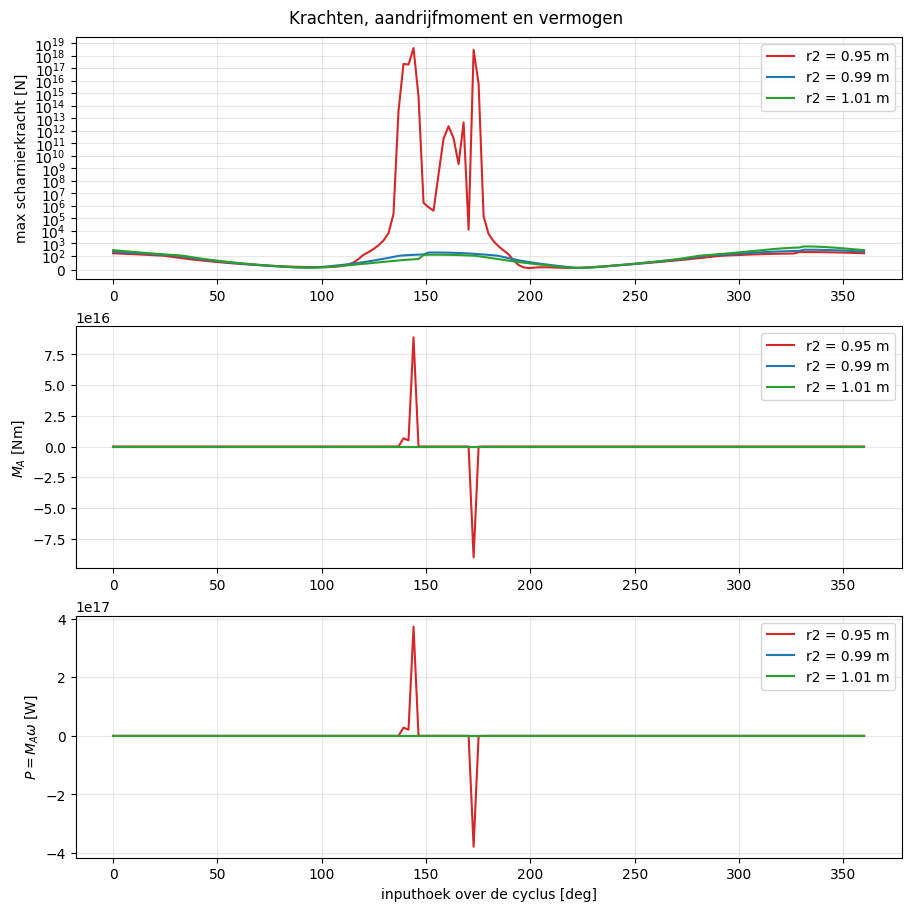

In [9]:

colors = {0.95: 'tab:red', 0.99: 'tab:blue', 1.01: 'tab:green'}

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(9, 9), constrained_layout=True)
fig.suptitle('Krachten, aandrijfmoment en vermogen')
for r2, result in results.items():
    x = result['theta1_cycle_deg']
    label = f'r2 = {r2:.2f} m'
    ax[0].plot(x, result['max_force_t'], color=colors[r2], label=label)
    ax[1].plot(x, result['M_A'], color=colors[r2], label=label)
    ax[2].plot(x, result['P_motor'], color=colors[r2], label=label)

ax[0].set_ylabel('max scharnierkracht [N]')
ax[0].set_yscale('symlog', linthresh=100)
ax[1].set_ylabel('$M_A$ [Nm]')
ax[2].set_ylabel(r'$P=M_A\omega$ [W]')
ax[2].set_xlabel('inputhoek over de cyclus [deg]')
for axis in ax:
    axis.legend()
plt.show()


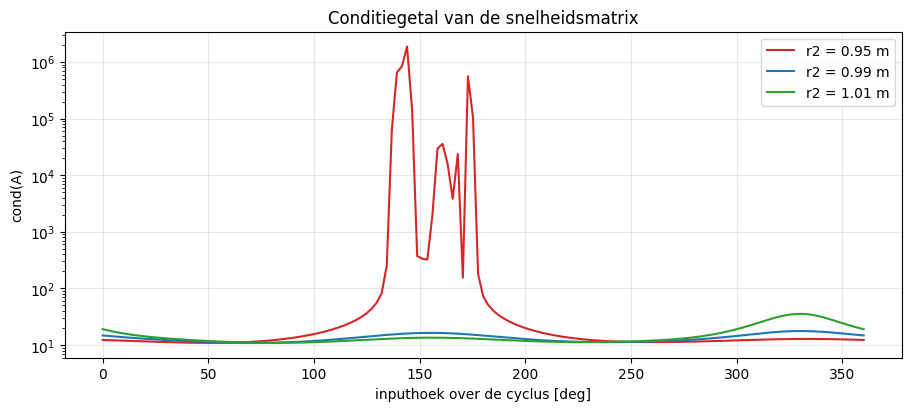

In [10]:

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
for r2, result in results.items():
    ax.plot(result['theta1_cycle_deg'], result['cond'], color=colors[r2], label=f'r2 = {r2:.2f} m')
ax.set_title('Conditiegetal van de snelheidsmatrix')
ax.set_xlabel('inputhoek over de cyclus [deg]')
ax.set_ylabel('cond(A)')
ax.set_yscale('log')
ax.legend()
plt.show()


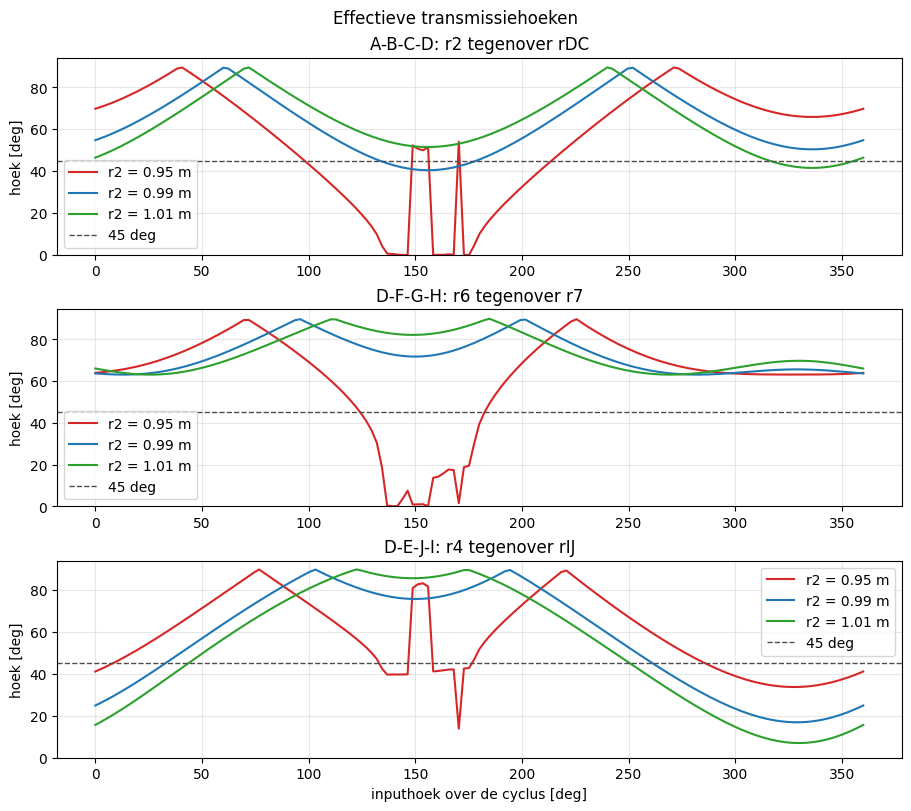

In [11]:

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(9, 8), constrained_layout=True)
fig.suptitle('Effectieve transmissiehoeken')
angle_specs = [
    ('gamma_BCD', 'A-B-C-D: r2 tegenover rDC'),
    ('gamma_FGH', 'D-F-G-H: r6 tegenover r7'),
    ('gamma_EJI', 'D-E-J-I: r4 tegenover rIJ'),
]
for axis, (key, title) in zip(ax, angle_specs):
    for r2, result in results.items():
        axis.plot(result['theta1_cycle_deg'], np.rad2deg(result[key]), color=colors[r2], label=f'r2 = {r2:.2f} m')
    axis.axhline(45, color='0.3', linestyle='--', linewidth=1, label='45 deg')
    axis.set_title(title)
    axis.set_ylabel('hoek [deg]')
    axis.set_ylim(bottom=0)
ax[-1].set_xlabel('inputhoek over de cyclus [deg]')
for axis in ax:
    axis.legend()
plt.show()



# Interpretatie

Gebruik vooral `cond max`, de minimale transmissiehoeken en de piekwaarden samen. Een kleinste transmissiehoek dicht bij 0 graden betekent dat een lus bijna in toggle/op-lijning staat. Dan wordt dezelfde beweging numeriek en fysisch slecht geconditioneerd: kleine versnellingen of belastingen veroorzaken zeer grote interne krachten.

Voor deze drie gevallen is `r2 = 0.95 m` de gevaarlijke variant: de lus A-B-C-D komt bijna in oplijning, waardoor het conditiegetal en de krachten zeer sterk stijgen. `r2 = 0.99 m` blijft veel rustiger. `r2 = 1.01 m` verhoogt vooral de belasting in de rechter ruitenwisserlus, maar blijft in deze vergelijking veel minder extreem dan de bijna-oplijning bij `r2 = 0.95 m`.
